# 🌍 Earthquake Analysis 2000–2025: Land vs Offshore

Earthquakes occur every day across the world, but they do not all have the same characteristics. Some happen on land, while many occur offshore, often along tectonic plate boundaries.

This project focuses on whether the **location of an earthquake – land or offshore – is associated with differences in its magnitude and depth**.

## Project Question

**Do offshore earthquakes differ from land earthquakes in terms of magnitude and depth?**

The analysis focuses on earthquakes with a magnitude of **5.0 or higher** recorded between **2000 and 2025**.

The **M5.0 threshold** was selected to focus the analysis on stronger earthquake events and maintain a clearly defined study scope.

## Data Source

The analysis is based on earthquake records from the **[U.S. Geological Survey (USGS) Earthquake Catalog](https://earthquake.usgs.gov/earthquakes/search/)**.

Each row represents a single earthquake event and includes information such as its location, magnitude, depth and geographic coordinates.

Before starting the analysis, the data will be checked for **missing values, duplicates and incorrect data types**.

## Data Preparation

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

folder_path = '/content/drive/MyDrive/earthquake_project_data'

The earthquake data are stored in **five CSV files**, each covering a different part of the 2000–2025 study period. All files share the same **22-column structure**, so they can be combined into a single dataset for further analysis.

In [ ]:
df1 = pd.read_csv(os.path.join(folder_path, '2000-2004.csv'))
df2 = pd.read_csv(os.path.join(folder_path, '2005-2009.csv'))
df3 = pd.read_csv(os.path.join(folder_path, '2010-2014.csv'))
df4 = pd.read_csv(os.path.join(folder_path, '2015-2019.csv'))
df5 = pd.read_csv(os.path.join(folder_path, '2020-2025.csv'))

df_earthquakes = pd.concat(
    [df1, df2, df3, df4, df5],
    ignore_index=True
)

### Data Quality Check

In [ ]:
df_earthquakes['time'] = pd.to_datetime(df_earthquakes['time'])

print("Dataset shape:")
print(df_earthquakes.shape)

print("\nDuplicate event IDs:")
print(df_earthquakes['id'].duplicated().sum())

print("\nEvent types:")
print(df_earthquakes['type'].value_counts())

print("\nKey data types:")
print(df_earthquakes[['time', 'latitude', 'longitude', 'depth', 'mag']].dtypes)

Dataset shape:
(46462, 22)

Duplicate event IDs:
0

Event types:
type
earthquake    46462
Name: count, dtype: int64

Key data types:
time         datetime64[ns, UTC]
latitude                 float64
longitude                float64
depth                    float64
mag                      float64
dtype: object


In [ ]:
print("Missing values:")
print(df_earthquakes.isna().sum())

Missing values:
time                   0
latitude               0
longitude              0
depth                  0
mag                    0
magType                0
nst                15609
gap                 4971
dmin               25393
rms                 1135
net                    0
id                     0
updated                0
place                  0
type                   0
horizontalError    26924
depthError         17801
magError           27018
magNst             20684
status                 0
locationSource         0
magSource              0
dtype: int64


In [ ]:
print("Date range:")
print(df_earthquakes['time'].min(), "-", df_earthquakes['time'].max())

print("\nMagnitude range:")
print(df_earthquakes['mag'].min(), "-", df_earthquakes['mag'].max())

print("\nDepth range:")
print(df_earthquakes['depth'].min(), "-", df_earthquakes['depth'].max())

print("\nNegative depth values:")
print((df_earthquakes['depth'] < 0).sum())

Date range:
2000-01-01 05:24:35.290000+00:00 - 2025-12-31 14:26:57.992000+00:00

Magnitude range:
5.0 - 9.1

Depth range:
-1.77 - 691.6

Negative depth values:
4


The combined dataset contains **46,462 unique earthquake events** recorded between **2000 and 2025**. All records are classified as earthquakes, and the variables central to this analysis – **time, latitude, longitude, magnitude and depth** – contain no missing values.

Missing values occur mainly in additional technical measurement fields, which are not required for the main analytical question.

The observed magnitudes range from **5.0 to 9.1**, while earthquake depths range from **-1.77 km to 691.6 km**. Only **4 events have slightly negative depth values**. These observations were retained, as such values may occur depending on the reference level used to determine earthquake depth and represent only a marginal part of the dataset.

### Geographic Classification

To distinguish between **land and offshore earthquakes**, an additional spatial classification created in **QGIS** was used. Earthquake locations were assigned to country boundaries based on the **Natural Earth** dataset. Events located outside country polygons were classified as **OFFSHORE**.

The geographic classification was matched to the earthquake dataset using the unique event **ID** and then simplified into two groups: **Land** and **Offshore**. In this project, the offshore category therefore refers to events located outside the country polygons used in the spatial classification.

In [ ]:
df_geography = pd.read_csv(
    os.path.join(folder_path, 'Earthquakes_GeographyFinal.csv')
)

In [ ]:
df_earthquakes = pd.merge(
    df_earthquakes,
    df_geography[['id', 'geography_key']],
    on='id',
    how='left'
)

In [ ]:
print("Rows after merge:", len(df_earthquakes))
print("Unmatched geography records:", df_earthquakes['geography_key'].isna().sum())

Rows after merge: 46462
Unmatched geography records: 0


In [ ]:
df_earthquakes['location_type'] = 'Land'

df_earthquakes.loc[
    df_earthquakes['geography_key'] == 'OFFSHORE',
    'location_type'
] = 'Offshore'

## Earthquake Overview

Before comparing land and offshore earthquakes, it is useful to introduce the two main characteristics used throughout the analysis.

**Magnitude** describes the size of an earthquake. It is measured on a logarithmic scale, meaning that relatively small differences in magnitude represent substantial differences in earthquake size.

**Depth** describes how deep the earthquake originated and is reported in **kilometres**. Earthquakes can occur close to the surface or hundreds of kilometres below it.

### Global Distribution of Earthquakes

In [ ]:
fig = px.scatter_geo(
    df_earthquakes,
    lat='latitude',
    lon='longitude',
    color='location_type',
    opacity=0.45,
    labels={'location_type': 'Location type'},
    color_discrete_map={
        'Offshore': 'royalblue',
        'Land': 'darkorange'
    },
    title='Global Distribution of Earthquakes by Location Type (M5.0+, 2000–2025)'
)

fig.update_traces(marker=dict(size=3))

fig.update_geos(
    showland=True,
    landcolor='rgb(240, 240, 240)',
    showcountries=True,
    countrycolor='rgb(200, 200, 200)',
    showocean=True,
    oceancolor='rgb(230, 245, 255)'
)

fig.update_layout(
    margin=dict(l=0, r=0, t=50, b=0)
)

fig.show()

Earthquakes are not distributed evenly across the globe. They form distinct spatial belts, with particularly high concentrations around the **Pacific region**, along the western coasts of the Americas, around Japan and Indonesia, as well as along several mid-ocean zones.

The distinction between **land and offshore events** shows that many earthquakes in the dataset occur outside country land areas, particularly along oceanic seismic belts and around the Pacific.

This spatial pattern provides the first indication that offshore earthquakes form an important part of the dataset. The following analysis will quantify this difference and examine whether **land and offshore earthquakes also differ in magnitude and depth**.

### Magnitude Distribution

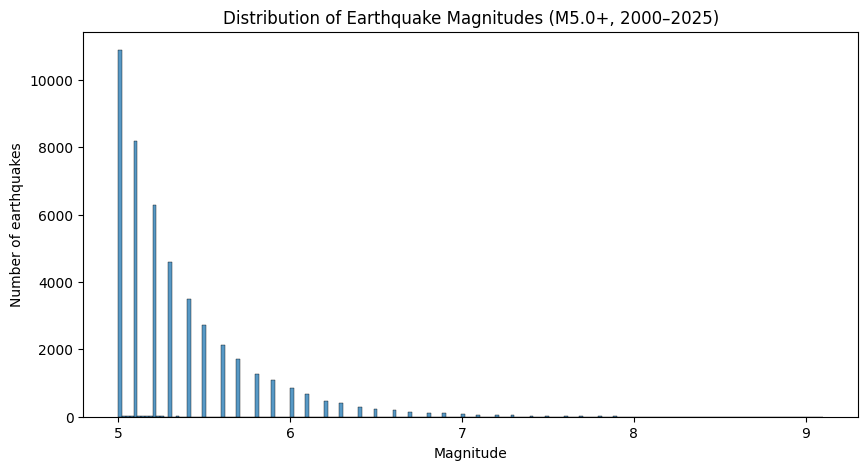

In [ ]:
plt.figure(figsize=(10, 5))

sns.histplot(data=df_earthquakes, x='mag')

plt.title('Distribution of Earthquake Magnitudes (M5.0+, 2000–2025)')
plt.xlabel('Magnitude')
plt.ylabel('Number of earthquakes')

plt.show()

Within the **M5.0+ dataset**, the magnitude distribution is strongly right-skewed. Most earthquakes are concentrated close to the **M5.0 threshold**, while events with higher magnitudes become progressively less frequent.

Earthquakes of **M7.0 and above** form only a small part of the dataset, with the strongest event reaching **M9.1**.

### Depth Distribution

Following the **U.S. Geological Survey (USGS)** depth classification, this analysis uses three depth groups: **shallow (<70 km)**, **intermediate (70–<300 km)** and **deep (≥300 km)**.

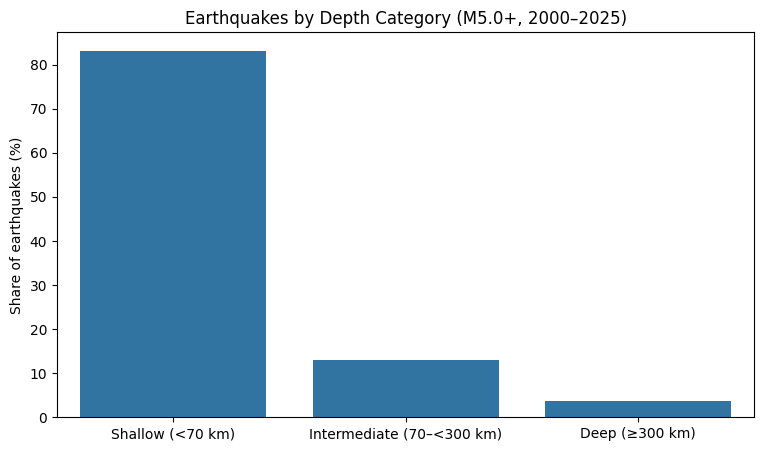

In [ ]:
shallow = (df_earthquakes['depth'] < 70).sum()

intermediate = (
    (df_earthquakes['depth'] >= 70) &
    (df_earthquakes['depth'] < 300)
).sum()

deep = (df_earthquakes['depth'] >= 300).sum()

depth_categories = pd.DataFrame({
    'Depth category': [
        'Shallow (<70 km)',
        'Intermediate (70–<300 km)',
        'Deep (≥300 km)'
    ],
    'Number of earthquakes': [
        shallow,
        intermediate,
        deep
    ]
})

depth_categories['Percentage'] = (
    depth_categories['Number of earthquakes']
    / depth_categories['Number of earthquakes'].sum()
    * 100
)

depth_order = [
    'Shallow (<70 km)',
    'Intermediate (70–<300 km)',
    'Deep (≥300 km)'
]

plt.figure(figsize=(9, 5))

sns.barplot(
    data=depth_categories,
    x='Depth category',
    y='Percentage',
    order=depth_order
)

plt.title('Earthquakes by Depth Category (M5.0+, 2000–2025)')
plt.xlabel('')
plt.ylabel('Share of earthquakes (%)')

plt.show()

Within the **M5.0+ dataset**, most earthquakes are **shallow (<70 km)**, accounting for approximately **83%** of all events.

Intermediate-depth earthquakes represent about **13%**, while deep earthquakes account for less than **4%** of the dataset.

The dataset is therefore strongly dominated by **shallow earthquakes**, which provides context for the later comparison between **land and offshore events**.

## Land vs Offshore Earthquakes

### Distribution of Earthquakes by Location Type

In [ ]:
location_share = (
    df_earthquakes['location_type']
    .value_counts(normalize=True)
    * 100
)

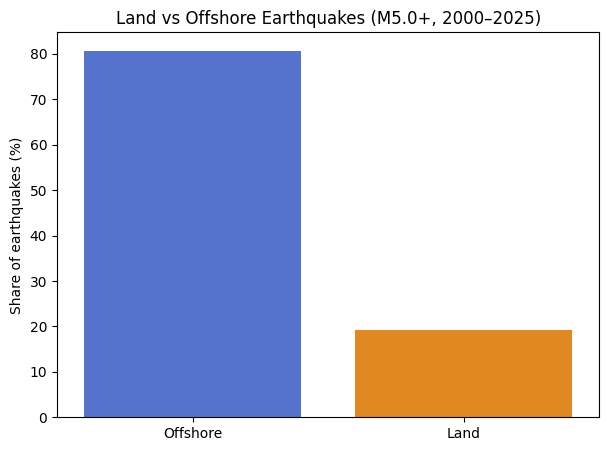

In [ ]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=location_share.index,
    y=location_share.values,
    hue=location_share.index,
    palette={
        'Offshore': 'royalblue',
        'Land': 'darkorange'
    },
    legend=False
)

plt.title('Land vs Offshore Earthquakes (M5.0+, 2000–2025)')
plt.xlabel('')
plt.ylabel('Share of earthquakes (%)')

plt.show()

Approximately **81% of the earthquakes in the dataset occurred offshore**, while only about **19% occurred on land**.

This confirms the spatial pattern observed earlier on the global map and shows that the two groups differ substantially in size.

The next step is to examine whether they also differ in their **magnitude and depth characteristics**.

### Descriptive Statistics

In [ ]:
descriptive_stats = (
    df_earthquakes
    .groupby('location_type')[['mag', 'depth']]
    .median()
    .round(2)
)

descriptive_stats.columns = ['Median magnitude', 'Median depth (km)']

descriptive_stats

,Median magnitude,Median depth (km)
location_type,,
Land,5.2,32.0
Offshore,5.2,22.0


The descriptive statistics show that the median earthquake magnitude is **5.2 for both land and offshore events**, suggesting very similar typical magnitude values.

A clearer difference appears in earthquake depth. The median depth is **32 km for land earthquakes** and **22 km for offshore earthquakes**.

These initial differences will be explored further through visualizations and statistical testing.

### Earthquakes Over Time: Land vs Offshore
Since offshore earthquakes make up the majority of the dataset, the next step is to examine whether this pattern was consistent throughout the **2000–2025 period**.

In [ ]:
df_earthquakes['year'] = df_earthquakes['time'].dt.year

In [ ]:
earthquakes_by_year = (
    df_earthquakes
    .groupby(['year', 'location_type'])
    .size()
    .reset_index(name='count')
)

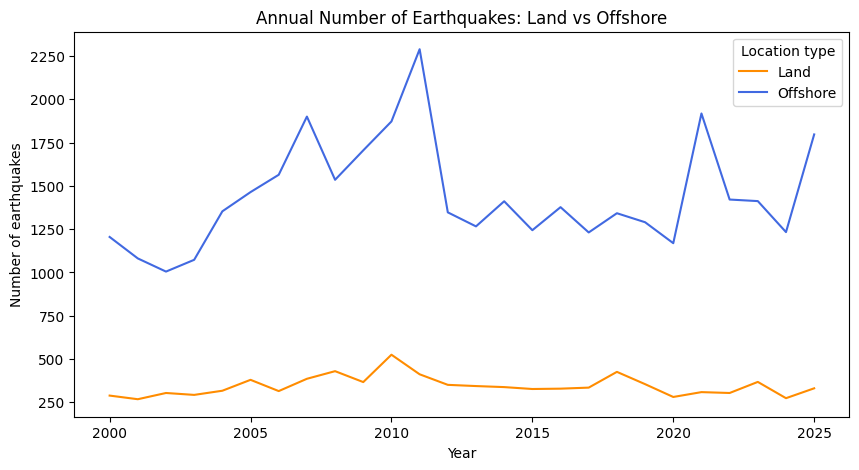

In [ ]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=earthquakes_by_year,
    x='year',
    y='count',
    hue='location_type',
    palette={
        'Offshore': 'royalblue',
        'Land': 'darkorange'
    }
)

plt.title('Annual Number of Earthquakes: Land vs Offshore')
plt.xlabel('Year')
plt.ylabel('Number of earthquakes')
plt.legend(title='Location type')
plt.show()

Offshore earthquakes were more frequent than land earthquakes in **every year between 2000 and 2025**.

This indicates that the overall dominance of offshore earthquakes in the dataset is **consistent across the entire study period**, rather than being driven by only a few individual years.

### Magnitude: Land vs Offshore
To compare the magnitude profiles of land and offshore earthquakes, events are grouped into three simple magnitude ranges: **M5.0–5.9, M6.0–6.9 and M7.0+**.

In [ ]:
df_earthquakes['magnitude_category'] = 'M5.0–5.9'

df_earthquakes.loc[
    (df_earthquakes['mag'] >= 6.0) &
    (df_earthquakes['mag'] < 7.0),
    'magnitude_category'
] = 'M6.0–6.9'

df_earthquakes.loc[
    df_earthquakes['mag'] >= 7.0,
    'magnitude_category'
] = 'M7.0+'

In [ ]:
magnitude_comparison = (
    df_earthquakes
    .groupby(['location_type', 'magnitude_category'])
    .size()
    .reset_index(name='count')
)

magnitude_comparison['percentage'] = (
    magnitude_comparison['count']
    / magnitude_comparison.groupby('location_type')['count'].transform('sum')
    * 100
)

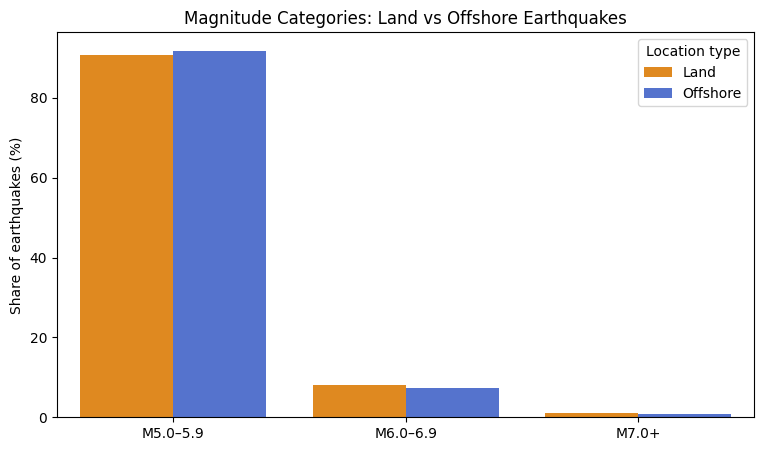

In [ ]:
magnitude_order = [
    'M5.0–5.9',
    'M6.0–6.9',
    'M7.0+'
]

plt.figure(figsize=(9, 5))

sns.barplot(
    data=magnitude_comparison,
    x='magnitude_category',
    y='percentage',
    hue='location_type',
    order=magnitude_order,
    palette={
        'Offshore': 'royalblue',
        'Land': 'darkorange'
    }
)

plt.title('Magnitude Categories: Land vs Offshore Earthquakes')
plt.xlabel('')
plt.ylabel('Share of earthquakes (%)')
plt.legend(title='Location type')
plt.show()

The magnitude structure is very similar for land and offshore earthquakes.

In both groups, the vast majority of events fall within the **M5.0–5.9 category**, while earthquakes with magnitudes of **M6.0–6.9** are much less common. Events of **M7.0 and above** represent only a very small share of both groups.

The proportions across the three magnitude categories are very similar for land and offshore earthquakes, indicating that their **magnitude profiles appear broadly comparable**.

### Depth: Land vs Offshore
Using the same depth categories introduced earlier, the following comparison examines whether the **depth structure differs between land and offshore earthquakes**.

In [ ]:
df_earthquakes['depth_category'] = 'Shallow (<70 km)'

df_earthquakes.loc[
    (df_earthquakes['depth'] >= 70) &
    (df_earthquakes['depth'] < 300),
    'depth_category'
] = 'Intermediate (70–<300 km)'

df_earthquakes.loc[
    df_earthquakes['depth'] >= 300,
    'depth_category'
] = 'Deep (≥300 km)'

In [ ]:
depth_comparison = (
    df_earthquakes
    .groupby(['location_type', 'depth_category'])
    .size()
    .reset_index(name='count')
)

depth_comparison['percentage'] = (
    depth_comparison['count']
    / depth_comparison.groupby('location_type')['count'].transform('sum')
    * 100
)

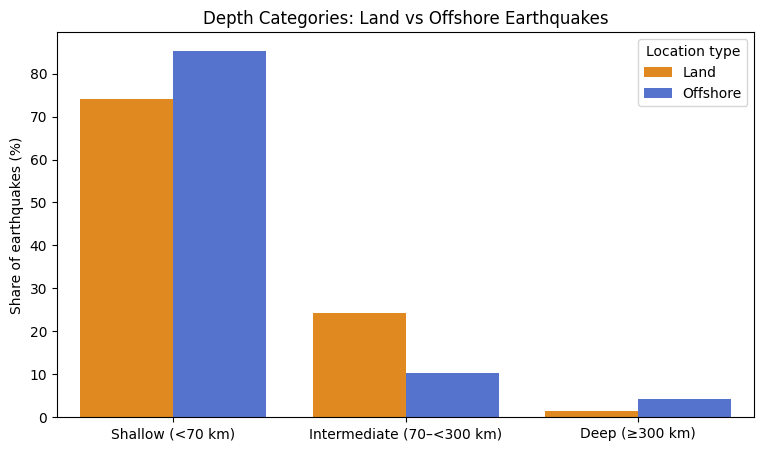

In [ ]:
depth_order = [
    'Shallow (<70 km)',
    'Intermediate (70–<300 km)',
    'Deep (≥300 km)'
]

plt.figure(figsize=(9, 5))

sns.barplot(
    data=depth_comparison,
    x='depth_category',
    y='percentage',
    hue='location_type',
    order=depth_order,
    palette={
        'Offshore': 'royalblue',
        'Land': 'darkorange'
    }
)

plt.title('Depth Categories: Land vs Offshore Earthquakes')
plt.xlabel('')
plt.ylabel('Share of earthquakes (%)')
plt.legend(title='Location type')
plt.show()

The depth structure differs noticeably between land and offshore earthquakes.

Although **shallow earthquakes dominate in both groups**, they account for a larger share of offshore events – approximately **85%**, compared with **74%** for land earthquakes.

The largest contrast appears among **intermediate-depth earthquakes**, which represent about **24% of land events but only 10% of offshore events**. Deep earthquakes are relatively rare in both groups.

Overall, the visualization suggests that the **depth distributions of land and offshore earthquakes differ**. The next section will determine whether this difference is statistically significant.

## Statistical Tests

The exploratory analysis showed that both **magnitude and depth have asymmetric distributions**, with most observations concentrated at lower magnitudes and shallower depths.

Since the analysis compares two independent groups – **Land and Offshore** – a non-parametric **Mann–Whitney U test** will be used to compare their distributions without assuming normality.

The tests are two-sided, as the aim is to determine whether the groups differ rather than to assume the direction of the difference in advance. The significance level is set at **α = 0.05**.

### Magnitude: Mann–Whitney U Test

**H₀:** The distribution of earthquake magnitude does not differ between land and offshore earthquakes.

**H₁:** The distribution of earthquake magnitude differs between land and offshore earthquakes.

In [ ]:
from scipy.stats import mannwhitneyu

land_mag = df_earthquakes.loc[
    df_earthquakes['location_type'] == 'Land',
    'mag'
]

offshore_mag = df_earthquakes.loc[
    df_earthquakes['location_type'] == 'Offshore',
    'mag'
]

statistic, p_value = mannwhitneyu(land_mag, offshore_mag)

print("U statistic:", statistic)
print("p-value:", p_value)

U statistic: 166458762.5
p-value: 0.17719392890488983


The Mann–Whitney U test returned a **p-value of 0.177**, which is above the significance level of **0.05**. Therefore, the null hypothesis is not rejected.

The analysis does not indicate a statistically significant difference in the **magnitude distributions of land and offshore earthquakes**.

This result is consistent with the earlier descriptive statistics and visualization: both groups have a median magnitude of **5.2** and very similar proportions across the magnitude categories.

### Depth: Mann–Whitney U Test

**H₀:** The distribution of earthquake depth does not differ between land and offshore earthquakes.

**H₁:** The distribution of earthquake depth differs between land and offshore earthquakes.

In [ ]:
land_depth = df_earthquakes.loc[
    df_earthquakes['location_type'] == 'Land',
    'depth'
]

offshore_depth = df_earthquakes.loc[
    df_earthquakes['location_type'] == 'Offshore',
    'depth'
]

statistic, p_value = mannwhitneyu(land_depth, offshore_depth)

print("U statistic:", statistic)
print("p-value:", p_value)

U statistic: 185732565.5
p-value: 7.51475067339993e-57


In [ ]:
print("Land median depth:", land_depth.median())
print("Offshore median depth:", offshore_depth.median())

Land median depth: 32.0
Offshore median depth: 22.0


The Mann–Whitney U test returned a **p-value below 0.001**, indicating a statistically significant difference in depth between land and offshore earthquakes.

The median depth is **32 km for land earthquakes** and **22 km for offshore earthquakes**. Descriptively, land earthquakes therefore have a higher median depth.

This result is consistent with the earlier visualization, where land earthquakes had a much larger share of **intermediate-depth events** than offshore earthquakes.

## Limitations

The analysis includes only earthquakes of **M5.0 and above** recorded between **2000 and 2025**, so the results do not represent smaller earthquake events.

The **Land/Offshore** classification is based on Natural Earth country polygons. In this project, Offshore refers to events located outside these polygons rather than to a geological classification of oceanic and continental crust.

The comparison of **Land and Offshore event counts** is based on raw numbers and is not adjusted for differences in the surface area of land and offshore regions.

## Conclusions

This analysis compared **land and offshore earthquakes of M5.0 and above** recorded between 2000 and 2025, focusing on their frequency, magnitude and depth.

The main findings are:

- Approximately **81% of earthquakes occurred offshore**, while about **19% occurred on land**.
- Offshore earthquakes were more frequent than land earthquakes in **every year of the study period**.
- The median magnitude was **5.2 for both groups**.
- The Mann–Whitney U test found **no statistically significant difference in magnitude** between land and offshore earthquakes (**p = 0.177**).
- Earthquake depth showed a clearer difference. The median depth was **32 km for land earthquakes** and **22 km for offshore earthquakes**.
- The Mann–Whitney U test **found a statistically significant difference in depth** between the two groups (**p < 0.001**).
- Shallow earthquakes dominated both groups, but **intermediate-depth earthquakes were considerably more common among land events**.

Overall, the results suggest that **land and offshore earthquakes differ more clearly in terms of depth than magnitude**. While their magnitude distributions are similar, land earthquakes have a **higher median depth** than offshore earthquakes in this dataset.